In [3]:
from buildstock_query import BuildStockQuery
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)
import matplotlib.pyplot as plt
import datetime
import numpy as np
import seaborn as sns
import shapely
import geopandas as gpd
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
import plotly.express as px
from PIL import Image
from matplotlib import patches
import re
import os
import kaleido
from functools import reduce
import plotly.graph_objects as go
import matplotlib.colors as mpl_colors
import nbformat

In [4]:
# read parquet timeseries files from each upgrade
ts0 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up00/bldg0000003.parquet')
ts1 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up01/bldg0000003.parquet')
ts2 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up02/bldg0000003.parquet')

#ts0_jes = pd.read_parquet('C:/Users/pwhite2/OneDrive - NREL/Documents/GitHub/2025_sdr/resstock/project_national/sdr_upgrades_tmy3_jes_v2/simulation_output/timeseries/up00/bldg0001014.parquet')

In [5]:
def plot_individual_timeseries_pqt(ts_df, base_df, start_month, start_day, end_month, end_day, year, title, limit, legend_present):
    ts0 = ts_df
    ts0_cols = list(ts0.columns.values)
    enduse_list = [            
              'weather__drybulb_temperature__f',
              'energy_use__total__kbtu',
              'energy_use__net__kbtu', 
              'fuel_use__electricity__total__kwh',
              'fuel_use__electricity__net__kwh',
              'fuel_use__natural_gas__total__kbtu',
              'end_use__electricity__cooling__kwh', 
              'end_use__electricity__cooling_fans_pumps__kwh',
              'end_use__electricity__ceiling_fan__kwh',
              'end_use__electricity__heating__kwh',
              'end_use__electricity__heating_fans_pumps__kwh',
              'end_use__electricity__heating_heat_pump_backup__kwh',
              'end_use__electricity__heating_heat_pump_backup_fans_pumps__kwh', 
              'end_use__electricity__mech_vent__kwh',
              'end_use__electricity__hot_water__kwh', 
              'end_use__electricity__lighting_interior__kwh',
              'end_use__electricity__lighting_exterior__kwh',
              'end_use__electricity__lighting_garage__kwh',
              'end_use__electricity__well_pump__kwh',
              'end_use__electricity__permanent_spa_heater__kwh',
              'end_use__electricity__permanent_spa_pump__kwh',
              'end_use__electricity__pool_heater__kwh',
              'end_use__electricity__pool_pump__kwh',
              'end_use__electricity__plug_loads__kwh',
              'end_use__electricity__range_oven__kwh',
              'end_use__electricity__clothes_dryer__kwh',
              'end_use__electricity__clothes_washer__kwh',
              'end_use__electricity__dishwasher__kwh',
              'end_use__electricity__freezer__kwh',
              'end_use__electricity__refrigerator__kwh',
              'end_use__electricity__television__kwh',
              'end_use__natural_gas__heating__kbtu',
              'end_use__natural_gas__hot_water__kbtu'
       ]
    enduse_diff = list(set(enduse_list).difference(ts0_cols))
    
    for i in enduse_diff:
        ts0[str(i)] = np.nan
        
    ts0 = ts0.fillna(0)

    ts0 = ts0.fillna(0)

    ts0['end_use_electricity_appliances_kwh'] = (ts0.end_use__electricity__clothes_dryer__kwh + 
                                                    ts0.end_use__electricity__clothes_washer__kwh +
                                                    ts0.end_use__electricity__dishwasher__kwh +
                                                    ts0.end_use__electricity__freezer__kwh + 
                                                    ts0.end_use__electricity__refrigerator__kwh +
                                                    ts0.end_use__electricity__range_oven__kwh +
                                                    ts0.end_use__electricity__television__kwh) 

    ts0['end_use_electricity_misc_kwh'] = (ts0.end_use__electricity__plug_loads__kwh + 
                                                    ts0.end_use__electricity__pool_pump__kwh +
                                                    ts0.end_use__electricity__pool_heater__kwh +
                                                    ts0.end_use__electricity__permanent_spa_pump__kwh + 
                                                    ts0.end_use__electricity__permanent_spa_heater__kwh +
                                                    ts0.end_use__electricity__well_pump__kwh) 

    ts0['end_use_electricity_vent_fan_kwh'] = (ts0.end_use__electricity__mech_vent__kwh + 
                                                    ts0.end_use__electricity__ceiling_fan__kwh) 

    ts0['end_use_electricity_heating_kwh'] = (ts0.end_use__electricity__heating_fans_pumps__kwh +
                                                    ts0.end_use__electricity__heating__kwh) 

    ts0['end_use_electricity_hp_backup_kwh'] = (ts0.end_use__electricity__heating_heat_pump_backup__kwh +
                                                    ts0.end_use__electricity__heating_heat_pump_backup_fans_pumps__kwh) 

    ts0['end_use_electricity_cooling_kwh'] = (ts0.end_use__electricity__cooling__kwh + 
                                                    ts0.end_use__electricity__cooling_fans_pumps__kwh) 

    ts0['end_use_electricity_lighting_kwh'] = (ts0.end_use__electricity__lighting_interior__kwh + 
                                                    ts0.end_use__electricity__lighting_exterior__kwh +
                                                    ts0.end_use__electricity__lighting_garage__kwh)

    ts0['end_use__electricity__hot_water__kwh'] = ts0['end_use__electricity__hot_water__kwh'] 

    ts0['fuel_use__electricity__total__kwh'] = ts0['fuel_use__electricity__total__kwh']


    ts0['outdoor_temp_drybulb_f'] = ts0.weather__drybulb_temperature__f

    ts0['total_check'] = (ts0.end_use_electricity_hp_backup_kwh + 
                        ts0.end_use_electricity_heating_kwh + 
                        ts0.end_use_electricity_cooling_kwh + 
                        ts0.end_use__electricity__hot_water__kwh +
                        ts0.end_use_electricity_appliances_kwh +
                        ts0.end_use_electricity_misc_kwh +
                        ts0.end_use_electricity_vent_fan_kwh +
                        ts0.end_use_electricity_lighting_kwh)

    ts0['difference'] = ts0.total_check - ts0.fuel_use__electricity__total__kwh
    ts0['end_use_electricity_hp_backup_kwh_plt'] = ts0.end_use_electricity_hp_backup_kwh
    ts0['end_use_electricity_heating_kwh_plt'] = ts0.end_use_electricity_hp_backup_kwh_plt + ts0.end_use_electricity_heating_kwh
    ts0['end_use_electricity_cooling_kwh_plt'] = ts0.end_use_electricity_heating_kwh_plt + ts0.end_use_electricity_cooling_kwh
    ts0['end_use__electricity__hot_water__kwh_plt'] = ts0.end_use_electricity_cooling_kwh_plt + ts0.end_use__electricity__hot_water__kwh
    ts0['end_use_electricity_appliances_kwh_plt'] = ts0.end_use__electricity__hot_water__kwh_plt + ts0.end_use_electricity_appliances_kwh
    ts0['end_use_electricity_misc_kwh_plt'] = ts0.end_use_electricity_appliances_kwh_plt + ts0.end_use_electricity_misc_kwh
    ts0['end_use_electricity_vent_fan_kwh_plt'] = ts0.end_use_electricity_misc_kwh_plt + ts0.end_use_electricity_vent_fan_kwh
    ts0['end_use_electricity_lighting_kwh_plt'] = ts0.end_use_electricity_vent_fan_kwh_plt + ts0.end_use_electricity_lighting_kwh


    fig, ax1 = plt.subplots()

    MN_up1 = ts0
    ax2 = ax1.twinx()
    ax1.grid(zorder=0)
    ax1.plot(MN_up1.time, MN_up1.end_use_electricity_hp_backup_kwh_plt, color = '#d95f0e', label = 'Heat Pump Backup', zorder = 15)
    ax1.plot(MN_up1.time, MN_up1.end_use_electricity_heating_kwh_plt, color = '#EF1C21', label = 'Heating', zorder = 14)
    ax1.plot(MN_up1.time, MN_up1.end_use_electricity_cooling_kwh_plt, color = '#0071BD', label = 'Cooling', zorder = 16)
    ax1.plot(MN_up1.time, MN_up1.end_use__electricity__hot_water__kwh_plt, color = '#FFB239', label = 'Hot Water', zorder = 10)
    ax1.plot(MN_up1.time, MN_up1.end_use_electricity_appliances_kwh_plt, color = '#4A4D4A', label = 'Appliances', zorder = 11)
    ax1.plot(MN_up1.time, MN_up1.end_use_electricity_misc_kwh_plt, color = '#B5B2B5', label = 'Misc Loads', zorder = 12)
    ax1.plot(MN_up1.time, MN_up1.end_use_electricity_vent_fan_kwh_plt, color = '#FF79AD', label = 'Vent/Fan', zorder = 13)
    ax1.plot(MN_up1.time, MN_up1.end_use_electricity_lighting_kwh_plt, color = '#F7DF10', label = 'Lighting', zorder = 17)
    ax1.plot(MN_up1.time, MN_up1.fuel_use__electricity__total__kwh, color = 'black', label = 'Total', linewidth = '4')
    ax1.plot(MN_up1.time, base_df.fuel_use__electricity__total__kwh, color = 'black', label = 'Baseline', linestyle = 'dotted', linewidth = '2', zorder = 36)
    ax2.plot(MN_up1.time, MN_up1.outdoor_temp_drybulb_f, color = 'black', label = 'Outdoor Drybulb Temperature', linestyle = 'dashed', zorder = 37)

    ax1.grid(False, color = "grey", linewidth = "0.5", linestyle = "-", alpha = 0.5)

    # ng_colors = ['darkorange', 'firebrick', 'mediumpurple', 'dimgray', 'yellowgreen', 'gold']
    # elec_colors = ['darkorange', 'firebrick', 'paleturquoise', 'mediumpurple', 'dimgray', 'yellowgreen', 'silver', 'gold']
    # cmap_ng = LinearSegmentedColormap.from_list("my_colormap_ng", ng_colors)
    # cmap_elec = LinearSegmentedColormap.from_list("my_colormap_elec", elec_colors)
    # ng_labels = ['End Use: Heat Pump Backup', 'End Use: Heating','End Use: Hot Water', 'End Use: Appliances', 'End Use: Misc. Loads', 'End Use: Lighting']
    # elec_labels = ['End Use: Heat Pump Backup', 'End Use: Heating', 'End Use: Cooling',  'End Use: Hot Water', 'End Use: Appliances', 'End Use: Misc Loads', 'End Use: Vent/Fan', 'End Use: Lighting']

    ax1.set_ylabel('Average Electricity Demand [kW]')
    ax2.set_ylabel('Outdoor Drybulb Temperature [F]')
    ax1.set_xlabel('Day')
    fig.autofmt_xdate()
    ax1.set_xlim([datetime.date(year,start_month,start_day), datetime.date(year,end_month,end_day)])
    label_u = ''
    scale_y = 1
    ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x/scale_y))
    # ticks_y_f = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x * (9/5) + 32))
    ticks_y_f = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x))

    ax1.yaxis.set_major_formatter(ticks_y)
    ax2.yaxis.set_major_formatter(ticks_y_f)
    ylimit = limit
    ax1.set_ylim([0, ylimit])
    handles, labels = plt.gca().get_legend_handles_labels()
    order = [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
    # ax.legend([handles[idx] for idx in order], [elec_labels[idx] for idx in order], loc='upper center', bbox_to_anchor=(0.5, -0.25),
    #           fancybox=True, shadow=True, ncol=6)
    if legend_present == True:
        fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=4, fancybox=True, shadow=True, title = label_u)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

    ax1.fill_between(MN_up1.time, MN_up1.end_use_electricity_hp_backup_kwh_plt, 0, color = '#d95f0e', zorder = 16)
    ax1.fill_between(MN_up1.time, MN_up1.end_use_electricity_hp_backup_kwh_plt, MN_up1.end_use_electricity_heating_kwh_plt, color = '#EF1C21', zorder = 17, alpha = 0.5)
    ax1.fill_between(MN_up1.time, MN_up1.end_use_electricity_heating_kwh_plt, MN_up1.end_use_electricity_cooling_kwh_plt, color = '#0071BD', zorder = 18, alpha = 0.5)
    ax1.fill_between(MN_up1.time, MN_up1.end_use_electricity_cooling_kwh_plt, MN_up1.end_use__electricity__hot_water__kwh_plt, color = '#FFB239', zorder = 19, alpha = 0.5)
    ax1.fill_between(MN_up1.time, MN_up1.end_use__electricity__hot_water__kwh_plt, MN_up1.end_use_electricity_appliances_kwh_plt, color = '#4A4D4A', zorder = 20, alpha = 0.5)
    ax1.fill_between(MN_up1.time, MN_up1.end_use_electricity_appliances_kwh_plt, MN_up1.end_use_electricity_misc_kwh_plt, color = '#B5B2B5', zorder = 21, alpha = 0.5)
    ax1.fill_between(MN_up1.time, MN_up1.end_use_electricity_misc_kwh_plt, MN_up1.end_use_electricity_vent_fan_kwh_plt, color = '#FF79AD', zorder = 22, alpha = 0.5)
    ax1.fill_between(MN_up1.time, MN_up1.end_use_electricity_vent_fan_kwh_plt, MN_up1.end_use_electricity_lighting_kwh_plt, color = '#F7DF10', zorder = 23, alpha = 0.5)



    fig.suptitle(title, fontsize=12)

    # plt.legend()
    plt.show()


/var/folders/h5/f5pjbdjn0lb_dxf6cf5zg2tr0nrpt5/T/ipykernel_4077/2870922117.py:123: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(False, color = "grey", linewidth = "0.5", linestyle = "-", alpha = 0.5)


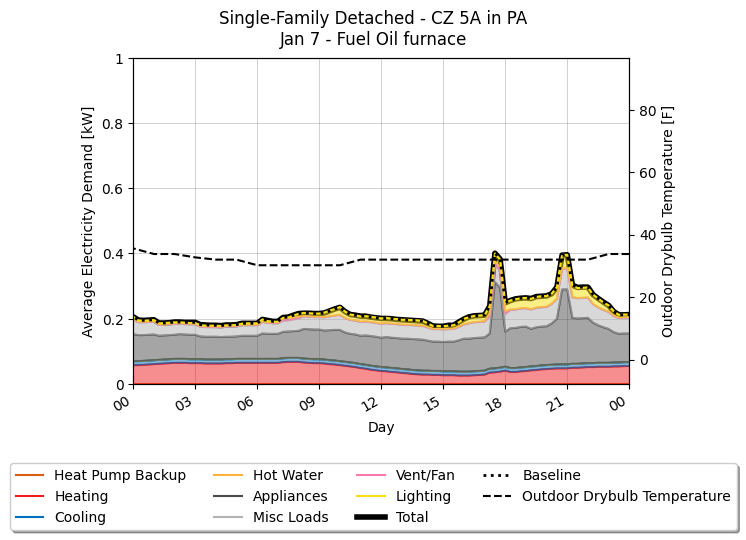

In [12]:
func_df = plot_individual_timeseries_pqt(ts0, base_df = ts0, start_month = 1, start_day = 7, end_month = 1, end_day = 8, year = 2018, title = 'Single-Family Detached - CZ 5A in PA\nJan 7 - Fuel Oil furnace', limit = 1, legend_present = True)

## MN propane oil! 

In [16]:
# read parquet timeseries files from each upgrade
ts0 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up00/bldg0000080.parquet')
ts1 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up01/bldg0000080.parquet')
ts2 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up02/bldg0000080.parquet')

#ts0_jes = pd.read_parquet('C:/Users/pwhite2/OneDrive - NREL/Documents/GitHub/2025_sdr/resstock/project_national/sdr_upgrades_tmy3_jes_v2/simulation_output/timeseries/up00/bldg0001014.parquet')

/var/folders/h5/f5pjbdjn0lb_dxf6cf5zg2tr0nrpt5/T/ipykernel_4077/2870922117.py:123: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax1.grid(False, color = "grey", linewidth = "0.5", linestyle = "-", alpha = 0.5)


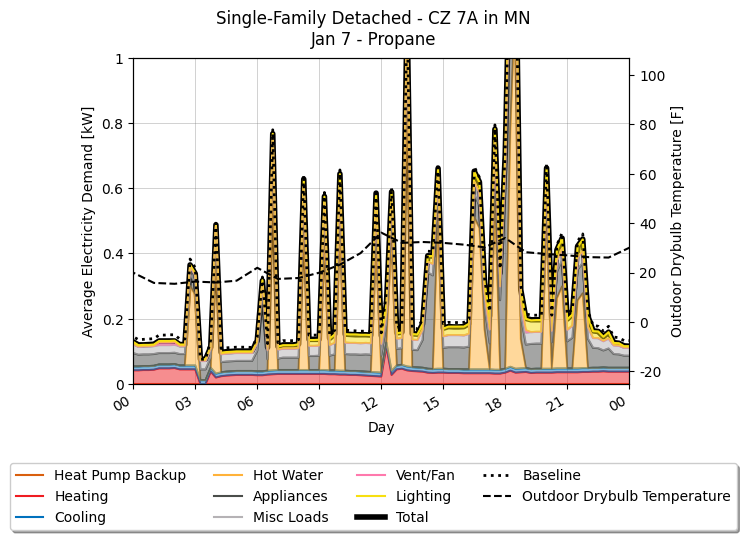

In [18]:
func_df = plot_individual_timeseries_pqt(ts1, base_df = ts0, start_month = 1, start_day = 7, end_month = 1, end_day = 8, year = 2018, title = 'Single-Family Detached - CZ 7A in MN\nJan 7 - Propane', limit = 1, legend_present = True)

In [ ]:
# read parquet timeseries files from each upgrade
ts0 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up00/bldg0000433.parquet')
ts1 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up01/bldg0000433.parquet')
ts2 = pd.read_parquet('/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up02/bldg0000433.parquet')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/kstenger/Documents/GitHub/demo/resstock/project_national/sdr_upgrades_furn_v3/simulation_output/timeseries/up02/bldg0000433.parquet'